In [3]:
import pandas as pd 

In [4]:
logon=pd.read_csv("C:/Users/shriy/Downloads/logon.csv")
file1=pd.read_csv("C:/Users/shriy/Downloads/file.csv")
device=pd.read_csv("C:/Users/shriy/Downloads/device.csv")
print("Successfull")

Successfull


### Preprocessing 

In [5]:
#Logon
logon.info()
logon.head()
#file1
file1.info()
file1.head()
#device
device.info()
device.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 854859 entries, 0 to 854858
Data columns (total 5 columns):
 #   Column    Non-Null Count   Dtype 
---  ------    --------------   ----- 
 0   id        854859 non-null  object
 1   date      854859 non-null  object
 2   user      854859 non-null  object
 3   pc        854859 non-null  object
 4   activity  854859 non-null  object
dtypes: object(5)
memory usage: 32.6+ MB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 445581 entries, 0 to 445580
Data columns (total 6 columns):
 #   Column    Non-Null Count   Dtype 
---  ------    --------------   ----- 
 0   id        445581 non-null  object
 1   date      445581 non-null  object
 2   user      445581 non-null  object
 3   pc        445581 non-null  object
 4   filename  445581 non-null  object
 5   content   445581 non-null  object
dtypes: object(6)
memory usage: 20.4+ MB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 405380 entries, 0 to 405379
Data columns (total 5 columns):
 # 

,id,date,user,pc,activity
0,{J1S3-L9UU75BQ-7790ATPL},01/02/2010 07:21:06,MOH0273,PC-6699,Connect
1,{N7B5-Y7BB27SI-2946PUJK},01/02/2010 07:37:41,MOH0273,PC-6699,Disconnect
2,{U1V9-Z7XT67KV-5649MYHI},01/02/2010 07:59:11,HPH0075,PC-2417,Connect
3,{H0Z7-E6GB57XZ-1603MOXD},01/02/2010 07:59:49,IIW0249,PC-0843,Connect
4,{L7P2-G4PX02RX-7999GYOY},01/02/2010 08:04:26,IIW0249,PC-0843,Disconnect


In [6]:
logon.isnull().sum()

id          0
date        0
user        0
pc          0
activity    0
dtype: int64

In [7]:
file1.isnull().sum()

id          0
date        0
user        0
pc          0
filename    0
content     0
dtype: int64

In [8]:
device.isnull().sum()

id          0
date        0
user        0
pc          0
activity    0
dtype: int64

In [9]:
#### Convert date columns
# Convert the 'date' column in the logon dataset to datetime format
# pd.to_datetime() converts a string date into a proper datetime object
# This allows us to extract useful time features like hour, day, month later
logon['date'] = pd.to_datetime(logon['date'])
device['date'] = pd.to_datetime(device['date'])
file1['date'] = pd.to_datetime(file1['date'])

In [10]:
#Removing unnen=cessary columns 
logon.drop(columns=['id'], inplace=True, errors='ignore')
device.drop(columns=['id'], inplace=True, errors='ignore')
file1.drop(columns=['id'], inplace=True, errors='ignore')

In [11]:
#Converting date columns
logon['date'] = pd.to_datetime(logon['date'])
device['date'] = pd.to_datetime(device['date'])
file1['date'] = pd.to_datetime(file1['date'])

In [12]:
#After converting date in string to datetime format we can use it for extracting time features
logon['hour'] = logon['date'].dt.hour
logon['day'] = logon['date'].dt.day
logon['month'] = logon['date'].dt.month

device['hour'] = device['date'].dt.hour
file1['hour'] = file1['date'].dt.hour

In [13]:
logon['date']
device['date']
file1['date']

0        2010-01-02 07:23:14
1        2010-01-02 07:26:19
2        2010-01-02 08:12:03
3        2010-01-02 08:17:00
4        2010-01-02 08:24:57
                 ...        
445576   2011-05-16 23:22:31
445577   2011-05-16 23:22:32
445578   2011-05-16 23:22:33
445579   2011-05-16 23:22:33
445580   2011-05-16 23:22:34
Name: date, Length: 445581, dtype: datetime64[ns]

In [14]:
logon['day_of_week'] = logon['date'].dt.dayofweek

logon['is_weekend'] = logon['day_of_week'].isin([5,6]).astype(int)

logon['is_night'] = ((logon['hour'] < 6) | (logon['hour'] > 22)).astype(int)

In [15]:
## Checking missing values or null values
#logon
print(logon.isnull().sum())
#device
print(device.isnull().sum())
#file1
print(file1.isnull().sum())

date           0
user           0
pc             0
activity       0
hour           0
day            0
month          0
day_of_week    0
is_weekend     0
is_night       0
dtype: int64
date        0
user        0
pc          0
activity    0
hour        0
dtype: int64
date        0
user        0
pc          0
filename    0
content     0
hour        0
dtype: int64


In [16]:
#As no null values exist...but if exist we use fillna()
logon.dropna(inplace=True)
device.dropna(inplace=True)
file1.dropna(inplace=True)

In [17]:
### Feature aggregation
login_features = logon.groupby('user').agg({
    'hour':'mean',
    'is_weekend':'sum',
    'is_night':'sum'
}).reset_index()

In [18]:
#device 
device_features = device.groupby('user').agg({
    'hour':'count'
}).rename(columns={'hour':'device_activity'}).reset_index()

In [19]:
#file1
file_features = file1.groupby('user').agg({
    'hour':'count'
}).rename(columns={'hour':'file_activity'}).reset_index()

### Data Integration

In [20]:
#Merged datasets
merged = login_features.merge(device_features, on='user', how='left')
merged = merged.merge(file_features, on='user', how='left')

In [21]:
merged.fillna(0, inplace=True)

In [22]:
print(merged.head())
print(merged.shape)

      user       hour  is_weekend  is_night  device_activity  file_activity
0  AAE0190  13.000000           0         0              0.0            0.0
1  AAF0535  12.521341           0         0            688.0          357.0
2  AAF0791  12.500000           0         0              0.0            0.0
3  AAL0706  11.510116           0         0              0.0            0.0
4  AAM0658  14.731441           2         9             13.0           31.0
(1000, 6)


In [23]:
merged.isnull().sum()

user               0
hour               0
is_weekend         0
is_night           0
device_activity    0
file_activity      0
dtype: int64

In [24]:
merged.shape

(1000, 6)

In [25]:
print(merged.dtypes)

user                object
hour               float64
is_weekend           int64
is_night             int64
device_activity    float64
file_activity      float64
dtype: object


In [26]:
print(merged.duplicated().sum())

0


In [27]:
merged.describe()

,hour,is_weekend,is_night,device_activity,file_activity
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,12.400633,20.159000,32.751000,405.380000,445.581000
std,0.888325,72.336397,145.393453,1234.481521,1461.941806
min,10.747573,0.000000,0.000000,0.000000,0.000000
25%,11.742119,0.000000,0.000000,0.000000,0.000000
50%,12.406438,0.000000,0.000000,0.000000,0.000000
75%,13.005128,0.000000,0.000000,14.000000,10.250000
max,15.347938,650.000000,1033.000000,8502.000000,11627.000000


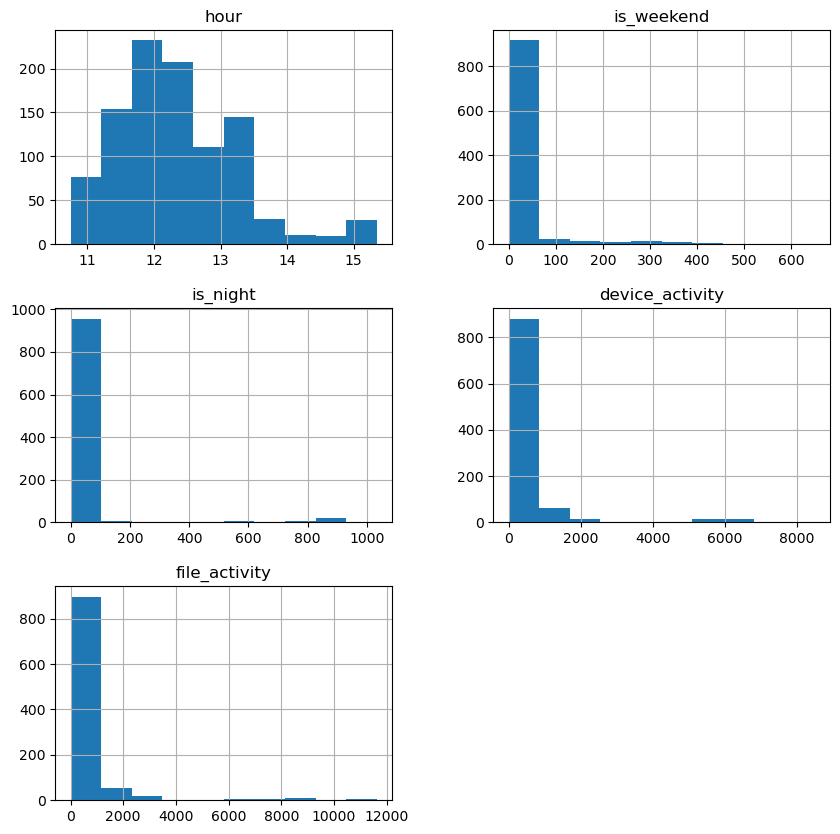

In [28]:
import matplotlib.pyplot as plt

merged.hist(figsize=(10,10))
plt.show()

In [29]:
#Data quality Score
missing = merged.isnull().sum().sum()
total = merged.size
quality = (1 - missing/total) * 100

print("Dataset completeness:", quality, "%")

Dataset completeness: 100.0 %


In [30]:
print(merged['hour'].min(), merged['hour'].max())

10.74757281553398 15.347938144329897


In [31]:
print(merged['user'].nunique())
print(len(merged))

1000
1000


In [32]:
merged.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   user             1000 non-null   object 
 1   hour             1000 non-null   float64
 2   is_weekend       1000 non-null   int64  
 3   is_night         1000 non-null   int64  
 4   device_activity  1000 non-null   float64
 5   file_activity    1000 non-null   float64
dtypes: float64(3), int64(2), object(1)
memory usage: 47.0+ KB


In [33]:
merged.head()

,user,hour,is_weekend,is_night,device_activity,file_activity
0,AAE0190,13.000000,0,0,0.0,0.0
1,AAF0535,12.521341,0,0,688.0,357.0
2,AAF0791,12.500000,0,0,0.0,0.0
3,AAL0706,11.510116,0,0,0.0,0.0
4,AAM0658,14.731441,2,9,13.0,31.0


In [34]:
print(merged.dtypes)

user                object
hour               float64
is_weekend           int64
is_night             int64
device_activity    float64
file_activity      float64
dtype: object


In [35]:
#Label Encoding 
'''Label Encoder():- Converts categorical text → numeric labels'''

'''Two operations happen:
1️. fit()= learns all unique user values
2️. transform()= replaces them with numeric labels'''
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()
merged['user'] = encoder.fit_transform(merged['user'])

In [36]:
print(merged.dtypes)

user                 int64
hour               float64
is_weekend           int64
is_night             int64
device_activity    float64
file_activity      float64
dtype: object


In [37]:
#Combinig data OR data integration 
merged_data = pd.merge(logon, device, on=['user', 'date'], how='outer')
merged_data = pd.merge(merged_data, file1, on=['user', 'date'], how='outer')

In [38]:
merged_data

,date,user,pc_x,activity_x,hour_x,day,month,day_of_week,is_weekend,is_night,pc_y,activity_y,hour_y,pc,filename,content,hour
0,2010-01-04 08:09:00,AAE0190,PC-8915,Logon,8.0,4.0,1.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2010-01-04 18:20:00,AAE0190,PC-8915,Logoff,18.0,4.0,1.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2010-01-05 08:19:00,AAE0190,PC-8915,Logon,8.0,5.0,1.0,1.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2010-01-05 18:11:00,AAE0190,PC-8915,Logoff,18.0,5.0,1.0,1.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2010-01-06 08:09:00,AAE0190,PC-8915,Logon,8.0,6.0,1.0,2.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1703614,2011-05-12 17:56:00,ZSL0305,PC-2640,Logoff,17.0,12.0,5.0,3.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1703615,2011-05-13 09:03:00,ZSL0305,PC-2640,Logon,9.0,13.0,5.0,4.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1703616,2011-05-13 17:58:00,ZSL0305,PC-2640,Logoff,17.0,13.0,5.0,4.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1703617,2011-05-16 09:05:00,ZSL0305,PC-2640,Logon,9.0,16.0,5.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [40]:
merged_data.to_csv("merged_dataset.csv", index=False)

In [39]:
logon.to_csv("cleaned_logon.csv", index=False)
device.to_csv("cleaned_device.csv", index=False)
file1.to_csv("cleaned_file.csv", index=False)

In [41]:
merged_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1703619 entries, 0 to 1703618
Data columns (total 17 columns):
 #   Column       Dtype         
---  ------       -----         
 0   date         datetime64[ns]
 1   user         object        
 2   pc_x         object        
 3   activity_x   object        
 4   hour_x       float64       
 5   day          float64       
 6   month        float64       
 7   day_of_week  float64       
 8   is_weekend   float64       
 9   is_night     float64       
 10  pc_y         object        
 11  activity_y   object        
 12  hour_y       float64       
 13  pc           object        
 14  filename     object        
 15  content      object        
 16  hour         float64       
dtypes: datetime64[ns](1), float64(8), object(8)
memory usage: 221.0+ MB
